C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


 report summary stats and hotspot metrics:
count    535.00
mean       3.79
std        4.59
min        0.30
25%        1.70
50%        2.30
75%        3.80
max       48.40
Name: as_ppm, dtype: float64
 median 2.30
skewness 4.66
Hotspot threshold (95th percentile): 10.66 ppm
Number of hotspot samples: 27


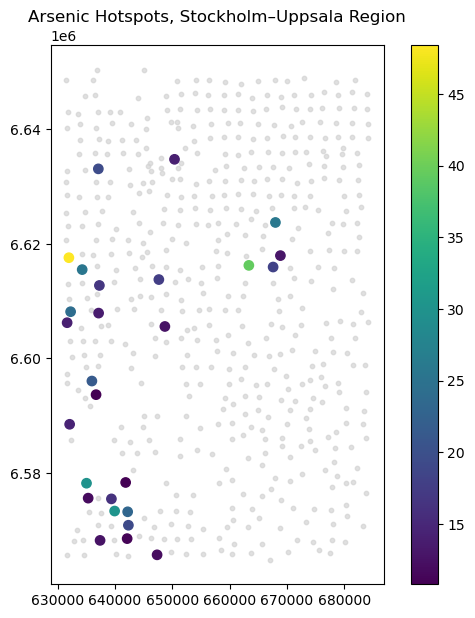

In [16]:
import geopandas as gpd
from pyproj import Transformer
import matplotlib.pyplot as plt

gpd.options.io_engine = "pyogrio" #faster engine
markgeokemi_icpms = gpd.read_file(
    "C:/Projects/markgeokemi/raw_data/markgeokemi_regional.gpkg",
    layer = "moran_0063mm_hno3_icpms",
    use_arrow = True
)
#Drop rows with missing ID/coordinates, ensure SWEREF system 
markgeokemi_icpms_clean = markgeokemi_icpms.dropna(   
    subset=[
        "unikt_id", "ns", "ew", "geometry"
    ]).set_crs("EPSG:3006", allow_override=True) 
# save cleaned data to GeoPackage
markgeokemi_icpms_clean.to_file(
     "C:/Projects/markgeokemi/cleaned_data/markgeokemi_icpms_clean.gpkg",
    driver= "GPKG")

#geographic bbox in WGS84; convert to SWEREF 99 TM
min_lat, max_lat = 59.20, 59.95
min_lon, max_lon = 17.30, 18.30
trans = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3006",
    always_xy = True
)
# convert bbox corners
min_ew, min_ns = trans.transform(min_lon, min_lat)  
max_ew, max_ns = trans.transform(max_lon, max_lat)

# keep valid (measured, >0) arsenic values within defined bbox
#0 → removes 0 (not analyzed
as_stoch_upp = markgeokemi_icpms_clean[
    (markgeokemi_icpms_clean["as_ppm"].notna()) & #removes missing values
    (markgeokemi_icpms_clean["as_ppm"] > 0) & # > 0 removes not analysed & below detection
    (markgeokemi_icpms_clean["ew"].between(min_ew, max_ew)) &
    (markgeokemi_icpms_clean["ns"].between(min_ns, max_ns))
][["unikt_id", "ns", "ew", "as_ppm", "geometry"]
].copy()

#summary stats for defined bbox
as_stoch_upp_stat = as_stoch_upp["as_ppm"].describe()
median_as_stoch_upp = as_stoch_upp["as_ppm"].median()
skew_as_stoch_upp = as_stoch_upp["as_ppm"].skew()

# define 95th percentile threshold; select top 5% (hotspots)
thresh_95 = as_stoch_upp["as_ppm"].quantile(0.95)
as_stoch_upp_hotspots = as_stoch_upp[
    as_stoch_upp["as_ppm"] >= thresh_95
].copy()
#report summary stats and hotspot metrics
print(f" report summary stats and hotspot metrics:")
print(as_stoch_upp_stat.round(2))
print(f" median {median_as_stoch_upp:.2f}")
print(f"skewness {skew_as_stoch_upp:.2f}")
print(f"Hotspot threshold (95th percentile): {thresh_95:.2f} ppm")
print(f"Number of hotspot samples: {len(as_stoch_upp_hotspots)}")

fig, ax = plt.subplots(figsize=(7, 7))
as_stoch_upp.plot(
    ax=ax,
    color="lightgrey",
    markersize=10,
    alpha=0.7
)
as_stoch_upp_hotspots.plot(
    column="as_ppm",
    legend=True,
    ax=ax,
    markersize=45
)
ax.set_title("Arsenic Hotspots, Stockholm–Uppsala Region")
plt.savefig(
    "C:/Projects/markgeokemi/results/as_stockholm_Uppsala_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()